In [41]:
from network_module import WeightedNetwork, AbstractNode, Message, visualize_graph
import networkx as nx
import random

In [42]:
class BFSTreeNode(AbstractNode):
    def __init__(self, node_id, neighbours):
        super().__init__(node_id, neighbours)
        self.state["done"] = False
        self.state["phase"] = "bfs"
        self.state["parent"] = -1
        self.state["children"] = []
        self.state["invites"] = []
        self.state["accepts"] = []
        self.state["round"] = -1
        self.state["value"] = random.randint(1, 10)
        self.state["converges"] = []

    def send_to_neighbours(self, message) -> None:
        for neighbour in self._neighbours:
            self.send_message(neighbour, message)

    def handle_message(self, message) -> None:
        if message.content["request"] == "invite":
            self.state["invites"].append(message.content["id"])
        elif message.content["request"] == "accept":
            self.state["accepts"].append(message.content["id"])
        elif message.content["request"] == "convergecast":
            self.state["converges"].append(message.content["value"])

    def bfs(self, source_id: int, round_number: int) -> None:
        # if the node is the source node
        if self.node_id == source_id and self.state["phase"] == "bfs":
            # send “invite” message to all neighbours
            self.send_to_neighbours({"id": self.node_id, "request": "invite"})
            # designate all neighbors as child nodes
            self.state["children"] = list(self._neighbours)

            self.state["phase"] = "convergecast"
            self.state["round"] = round_number

        elif self.state["parent"] == -1 and self.state["invites"]:
            self.state["round"] = round_number + 2

            parent = self.state["invites"][0]
            # send “accept” message to exactly one neighbour
            self.send_message(parent, {"id": self.node_id, "request": "accept"})
            # designate that neighbour as parent
            self.state["parent"] = parent

            # send “invite” message to all neighbours except new parent
            potential_children = [
                neighbour for neighbour in self._neighbours if neighbour != parent
            ]

            for node in potential_children:
                self.send_message(node, {"id": self.node_id, "request": "invite"})

        elif self.state["accepts"]:
            while self.state["accepts"]:
                new_child = self.state["accepts"].pop(0)
                if new_child not in self.state["children"]:
                    self.state["children"].append(new_child)

        if round_number == self.state["round"]:
            self.state["phase"] = "convergecast"

    def convergecast(self) -> None:
        # if the node is a leaf node
        if not self.state["children"]:
            self.send_message(
                self.state["parent"],
                {"request": "convergecast", "value": self.state["value"]},
            )

            self.state["phase"] = "terminated"

        elif len(self.state["converges"]) == len(self.state["children"]):
            max_value = max(self.state["converges"] + [self.state["value"]])

            if self.state["parent"] != -1:
                self.send_message(
                    self.state["parent"],
                    {"request": "convergecast", "value": max_value},
                )

                self.state["phase"] = "terminated"
            else:
                print(
                    f"I am the root, node {self.node_id} and the max value for this network is: {max_value}"
                )
                self.state["phase"] = "terminated"

    def compute(self, round_number: int) -> None:
        if self.state["phase"] == "bfs":
            self.bfs(source_id=1, round_number=round_number)

        if self.state["phase"] == "convergecast":
            self.convergecast()

On receiving an "invite" in round $i$ a node $v$ will set the sender of this "invite" as their parent $p$ and subsequently send "invite" messages to all nodes that are its neighbours and not their new parent $p$ i.e. $v$ sends "invite" messages to $\mathcal{N}(v) \setminus \{p\}$. In round $i + 1$ the children will recieve this "invite" and they might respond with an accept message. This accept message would then be recieved by $v$ in round $i + 2$. To terminate once the BFS has been constructed each node must keep track of the round when they accept a nodes invite and change a state variable. However, how will we know the global status? We might not be able to detect termination unless each node sends a finish message to their parent and these are collected at the root and the root then sends a terminate message through the tree. This also requires the root to know the number of nodes in the tree so they know how many messages to listen out for.

The method I will use is the following: at the end of round $i + 2$ a node knows its done because its got a parent and its tried to invite all possible children, and all of these possible children if they want $v$ to be their parent would've responded. At the end of this round $v$ will forward a "finished" message to its parent who will pass it up the tree to the source.

Once the source has received $n$ finish messges, its will broadcast a termination message in the BFS tree.

Now given that the next operation I would like to perform is a convergecast, it is sufficient for leaf nodes to start a convergecast after the $i + 2$ round. All non leaf nodes i.e. nodes with children can start running convergecast and just listen for the convergecast request.

In [43]:
# # Create an empty graph
# G = nx.Graph()

# # Add nodes
# G.add_nodes_from([1, 2, 3, 4])

# # Add edges with weights
# G.add_edge(1, 2, weight=1.5)
# G.add_edge(1, 3, weight=2.0)
# G.add_edge(2, 3, weight=2.5)
# G.add_edge(2, 4, weight=1.0)
# G.add_edge(3, 4, weight=3.0)

# G = nx.complete_graph(10)
# G = nx.complete_bipartite_graph(3, 5)
G = nx.barbell_graph(3, 3)

In [44]:
network = WeightedNetwork(G, BFSTreeNode)
network.run(20)
print(network)

I am the root, node 1 and the max value for this network is: 7
Network State:
Node 0:
  State: {'done': False, 'phase': 'terminated', 'parent': 1, 'children': [], 'invites': [1, 2], 'accepts': [], 'round': 3, 'value': 4, 'converges': []}
Node 1:
  State: {'done': False, 'phase': 'terminated', 'parent': -1, 'children': [0, 2], 'invites': [], 'accepts': [0, 2], 'round': 0, 'value': 4, 'converges': [4, 7]}
Node 2:
  State: {'done': False, 'phase': 'terminated', 'parent': 1, 'children': [3], 'invites': [1, 0], 'accepts': [], 'round': 3, 'value': 4, 'converges': [7]}
Node 3:
  State: {'done': False, 'phase': 'terminated', 'parent': 2, 'children': [4], 'invites': [2], 'accepts': [], 'round': 4, 'value': 5, 'converges': [7]}
Node 4:
  State: {'done': False, 'phase': 'terminated', 'parent': 3, 'children': [5], 'invites': [3], 'accepts': [], 'round': 5, 'value': 7, 'converges': [3]}
Node 5:
  State: {'done': False, 'phase': 'terminated', 'parent': 4, 'children': [6], 'invites': [4], 'accepts': 

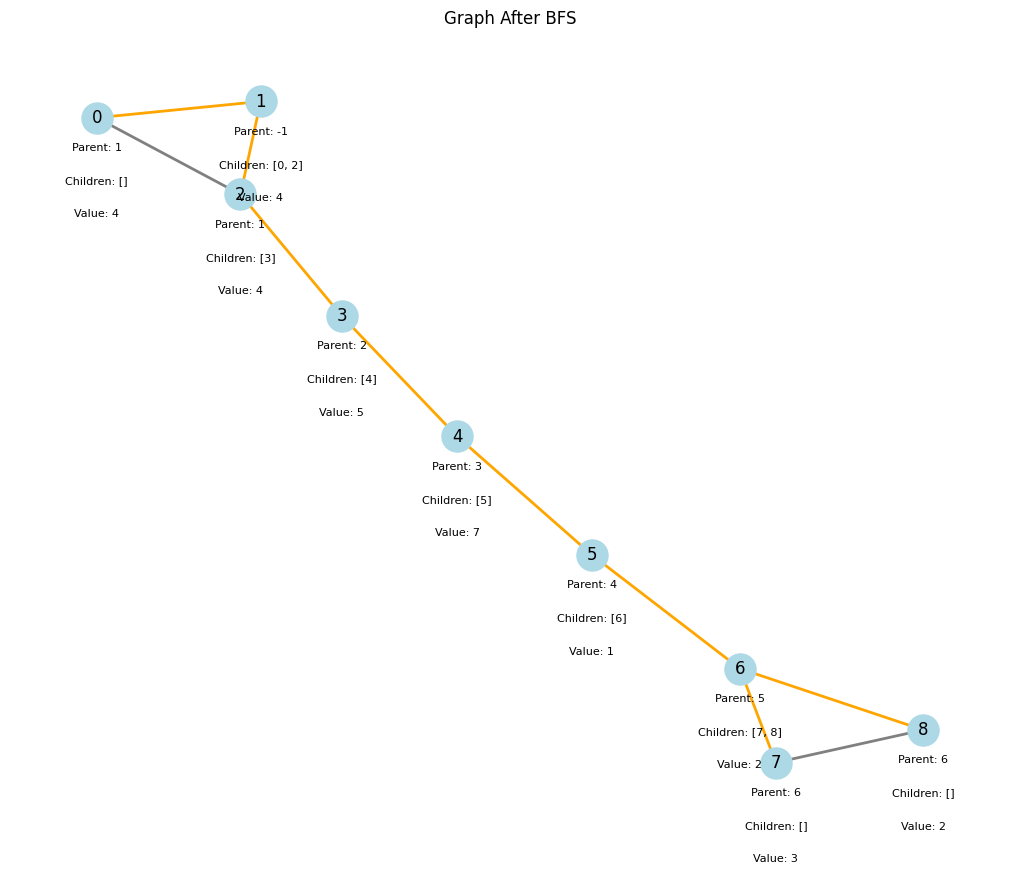

In [45]:
# Specify which states to display
node_states_to_display = ["parent", "children", "value"]

# Visualize the graph after BFS
visualize_graph(
    network.graph,
    network.nodes,
    title="Graph After BFS",
    node_states_to_display=node_states_to_display,
    show_bfs_tree=True,
)